### Marketing campaign clustering

In [8]:
import pandas as pd
import seaborn as sns
from datetime import datetime

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

In [2]:
# Zadanie 1
df = pd.read_csv("marketing_campaign.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   YearOfBirth          2240 non-null   int64  
 1   Education            2240 non-null   str    
 2   MaritalStatus        2240 non-null   str    
 3   Income               2216 non-null   float64
 4   KidsHome             2240 non-null   int64  
 5   TeensHome            2240 non-null   int64  
 6   CustomerFrom         2240 non-null   str    
 7   DaysLastPurchase     2240 non-null   int64  
 8   AmountWines          2240 non-null   int64  
 9   AmountFruits         2240 non-null   int64  
 10  AmountMeat           2240 non-null   int64  
 11  AmountFish           2240 non-null   int64  
 12  AmountSweets         2240 non-null   int64  
 13  AmountGoldProds      2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int64  
 16 

In [3]:
df.describe()

,YearOfBirth,Income,KidsHome,TeensHome,DaysLastPurchase,AmountWines,AmountFruits,AmountMeat,AmountFish,AmountSweets,AmountGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
count,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518
std,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000
50%,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000
75%,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000
max,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000


In [4]:
# Handle missing values from Income col (2216 out of 2240 records have income - 24 records missing)
df = df.drop(df[df["Income"].isnull()].index)

df.info() # Total 2216 records left in df after removing rows with null Income

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   YearOfBirth          2216 non-null   int64  
 1   Education            2216 non-null   str    
 2   MaritalStatus        2216 non-null   str    
 3   Income               2216 non-null   float64
 4   KidsHome             2216 non-null   int64  
 5   TeensHome            2216 non-null   int64  
 6   CustomerFrom         2216 non-null   str    
 7   DaysLastPurchase     2216 non-null   int64  
 8   AmountWines          2216 non-null   int64  
 9   AmountFruits         2216 non-null   int64  
 10  AmountMeat           2216 non-null   int64  
 11  AmountFish           2216 non-null   int64  
 12  AmountSweets         2216 non-null   int64  
 13  AmountGoldProds      2216 non-null   int64  
 14  NumDealsPurchases    2216 non-null   int64  
 15  NumWebPurchases      2216 non-null   int64  
 16  NumC

In [5]:
# Convert CustomerFrom column from str date (DD-MM-YYYY) to number of days from provided date up untill today
def get_days_from_today(date_str: str):
    target_date = datetime.strptime(date_str, '%d-%m-%Y').date()
    today = datetime.now().date()
    
    delta = today - target_date
    return delta.days

df["CustomerFrom"] = df["CustomerFrom"].apply(get_days_from_today)

In [6]:
# list all unique values from Education col
education_degrees = df["Education"].unique()
# based on this, ordered list for ordinal encoder class
education_ordered = [
    'Basic', 'Graduation', '2n Cycle', 'Master', 'PhD' 
]

ordinal_encoder = OrdinalEncoder(categories=[education_ordered])
encoded_education = ordinal_encoder.fit_transform(df[["Education"]])
df["Education"] = encoded_education

In [ ]:
# During EDA two records had 'YOLO' as MartialStatus and two had 'Absurd' -> qualified for dropping from dataset
martial_statuses = df["MaritalStatus"].unique()

df = df.drop(df[df["MaritalStatus"] == "YOLO"].index)
df = df.drop(df[df["MaritalStatus"] == "Absurd"].index)

married_cnt = df['MaritalStatus'].value_counts().get('Married', 0)
together_cnt = df['MaritalStatus'].value_counts().get('Together', 0)

widows_cnt = df['MaritalStatus'].value_counts().get('Widow', 0)
divorced_cnt = df['MaritalStatus'].value_counts().get('Divorced', 0)

alone_cnt = df['MaritalStatus'].value_counts().get('Alone', 0)
single_cnt = df['MaritalStatus'].value_counts().get('Single', 0)

martial_statues_cnts = f"""
Married cnt: {married_cnt}
Together cnt: {together_cnt}
Divorced cnt: {divorced_cnt}
Widows cnt: {widows_cnt}
Alone cnt: {alone_cnt}
Single cnt: {single_cnt}
"""

# Based on very similar structure of martial statuses, it's convinient to apply binning for feature engineering  
# 3 separate groups, single, in-relationship, after-relationship (aggregated widows + divorced - tough situation after marriage break-up or losing someone)
print(martial_statues_cnts)

def replace_martial_status(status: str) -> str:
    match status:
        case "Married" | "Together":
            return "In-relationship"
        case "Alone" | "Single":
            return "Single"
        case "Widow" | "Divorced":
            return "Tough breakup"
        
df["MaritalStatus"] = df["MaritalStatus"].map(replace_martial_status)

# Use one hot encoding for MartialStatus bins
one_hot_encoder = OneHotEncoder(drop="first", sparse_output=False)
martial_status_1hot_encoded = one_hot_encoder.fit_transform(df[["MaritalStatus"]])
martial_status_1hot_encoded_df = pd.DataFrame(martial_status_1hot_encoded, columns=one_hot_encoder.get_feature_names_out())

df = df.drop(labels=["MaritalStatus"], axis=1)
df = df.reset_index(drop=True)
df = pd.concat([df, martial_status_1hot_encoded_df], axis=1)


Married cnt: 857
Together cnt: 573
Divorced cnt: 232
Widows cnt: 76
Alone cnt: 3
Single cnt: 471



,YearOfBirth,Education,Income,KidsHome,TeensHome,CustomerFrom,DaysLastPurchase,AmountWines,AmountFruits,AmountMeat,AmountFish,AmountSweets,AmountGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,MaritalStatus_Single,MaritalStatus_Tough breakup
0,1957,1.0,58138.0,0,0,4992,58,635,88,546,172,88,88,3,8,10,4,7,1.0,0.0
1,1954,1.0,46344.0,1,1,4442,38,11,1,6,2,1,6,2,1,1,2,5,1.0,0.0
2,1965,1.0,71613.0,0,0,4641,26,426,49,127,111,21,42,1,8,2,10,4,0.0,0.0
3,1984,1.0,26646.0,1,0,4468,26,11,4,20,10,3,5,2,2,0,4,6,0.0,0.0
4,1981,4.0,58293.0,1,0,4490,94,173,43,118,46,27,15,5,5,3,6,5,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2207,1967,1.0,61223.0,0,1,4710,46,709,43,182,42,118,247,2,9,3,4,5,0.0,0.0
2208,1946,4.0,64014.0,2,1,4348,56,406,0,30,0,0,8,7,8,2,5,7,0.0,0.0
2209,1981,1.0,56981.0,0,0,4484,91,908,48,217,32,12,24,1,2,3,13,6,0.0,1.0
2210,1956,3.0,69245.0,0,1,4485,8,428,30,214,80,30,61,2,6,5,10,3,0.0,0.0


<Axes: ylabel='Income'>

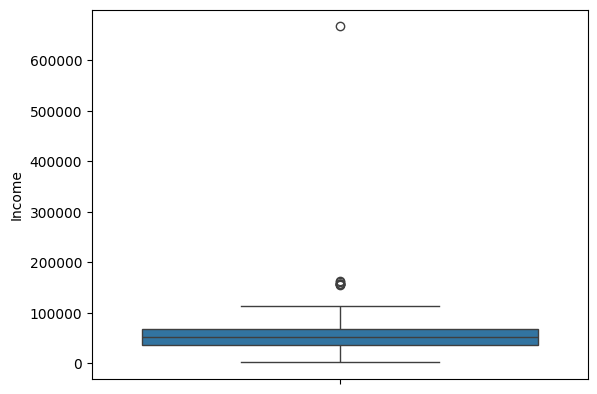

In [ ]:
# Explore data to find outliers from each numeric col

sns.boxplot(df["Income"]) 

<Axes: ylabel='KidsHome'>

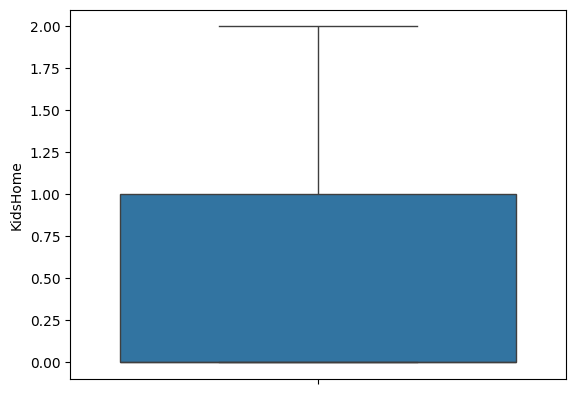

In [10]:
sns.boxplot(df["KidsHome"])

<Axes: ylabel='TeensHome'>

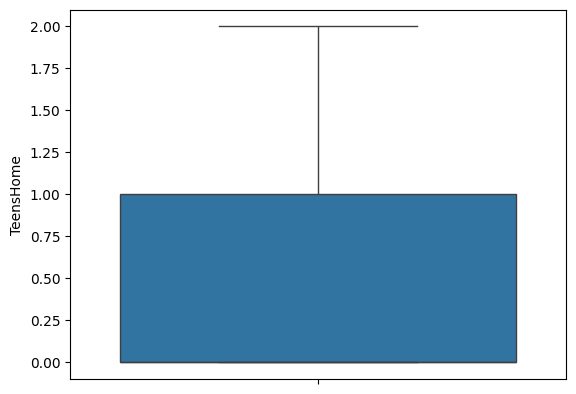

In [11]:
sns.boxplot(df["TeensHome"])

<Axes: ylabel='CustomerFrom'>

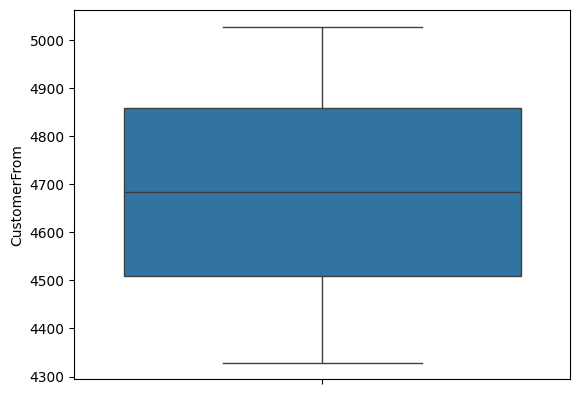

In [12]:
sns.boxplot(df["CustomerFrom"])

<Axes: ylabel='DaysLastPurchase'>

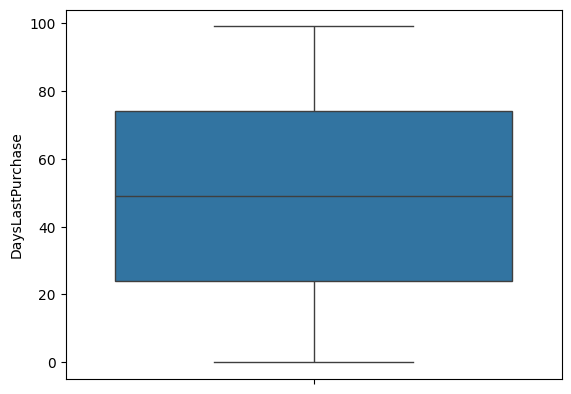

In [13]:
sns.boxplot(df["DaysLastPurchase"])

<Axes: ylabel='AmountWines'>

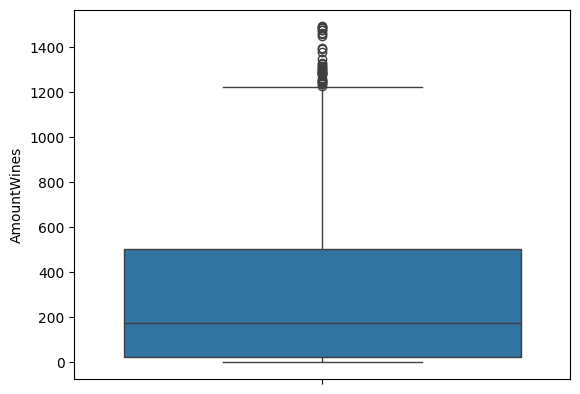

In [ ]:
sns.boxplot(df["AmountWines"]) 

<Axes: ylabel='AmountFruits'>

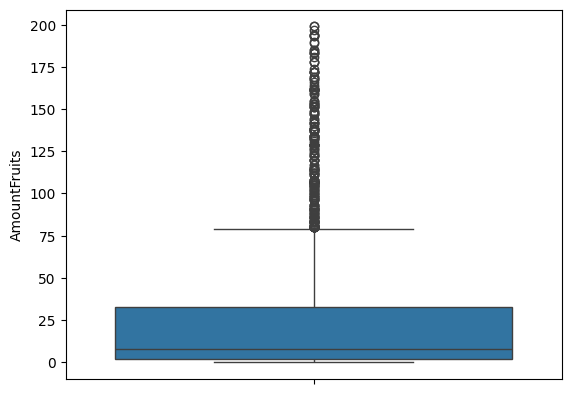

In [ ]:
sns.boxplot(df["AmountFruits"]) 

<Axes: ylabel='AmountMeat'>

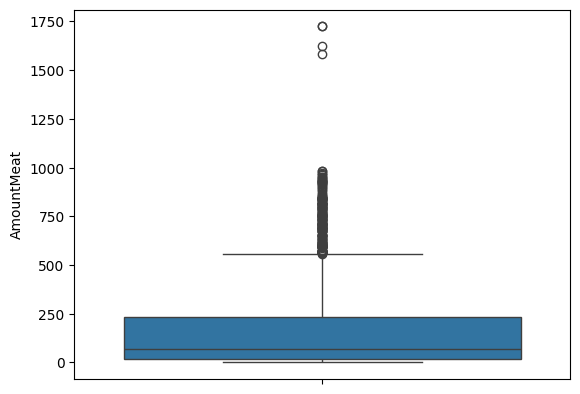

In [ ]:
sns.boxplot(df["AmountMeat"]) 

<Axes: ylabel='AmountFish'>

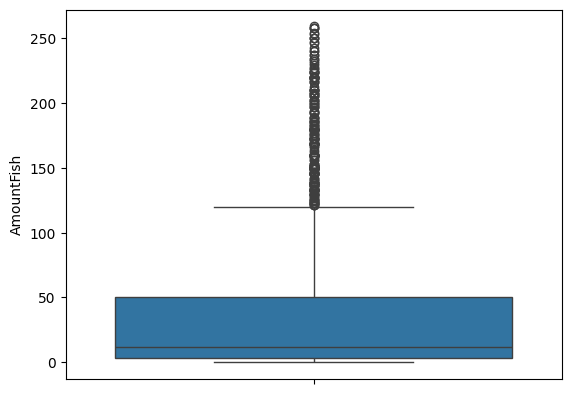

In [ ]:
sns.boxplot(df["AmountFish"]) 

<Axes: ylabel='AmountSweets'>

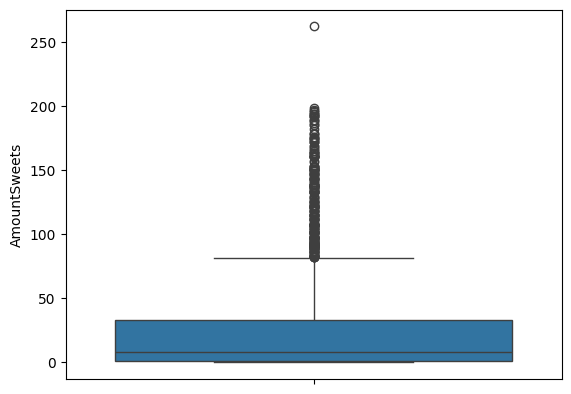

In [ ]:
sns.boxplot(df["AmountSweets"]) 

<Axes: ylabel='AmountGoldProds'>

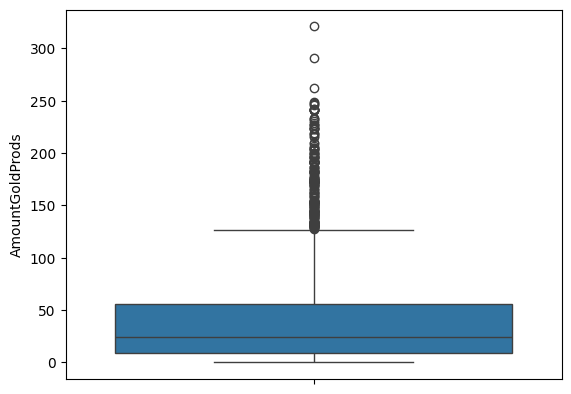

In [ ]:
sns.boxplot(df["AmountGoldProds"]) 

<Axes: ylabel='NumDealsPurchases'>

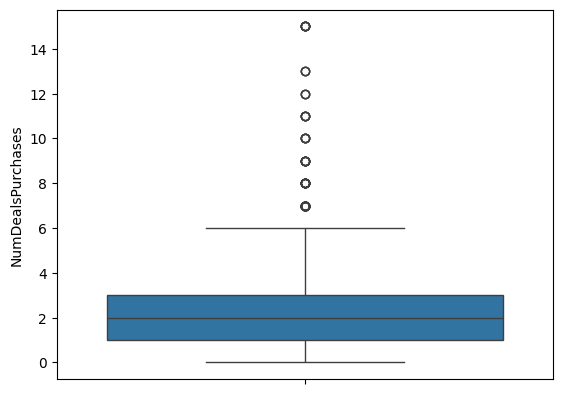

In [ ]:
sns.boxplot(df["NumDealsPurchases"]) 

<Axes: ylabel='NumWebPurchases'>

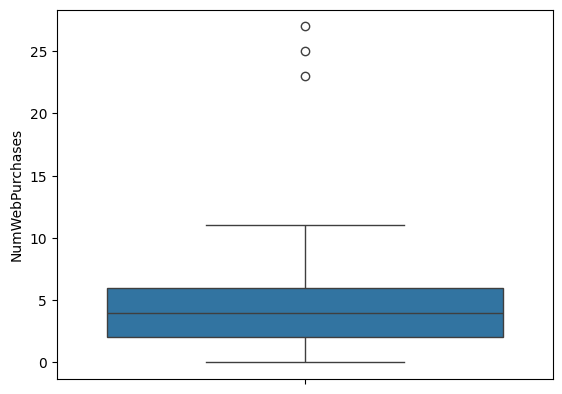

In [ ]:
sns.boxplot(df["NumWebPurchases"]) 

<Axes: ylabel='NumCatalogPurchases'>

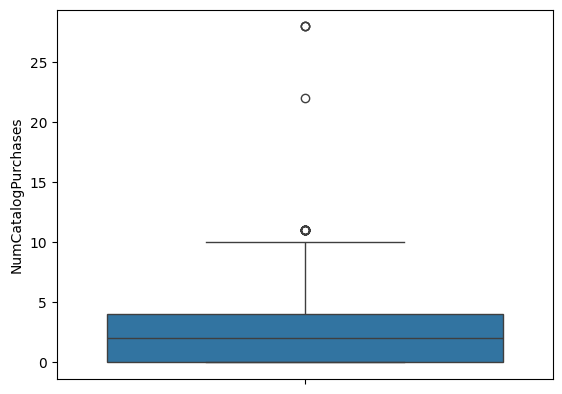

In [ ]:
sns.boxplot(df["NumCatalogPurchases"]) 

<Axes: ylabel='NumStorePurchases'>

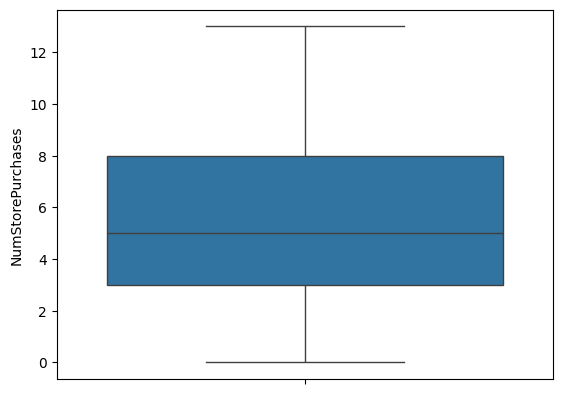

In [ ]:
sns.boxplot(df["NumStorePurchases"])

<Axes: ylabel='NumWebVisitsMonth'>

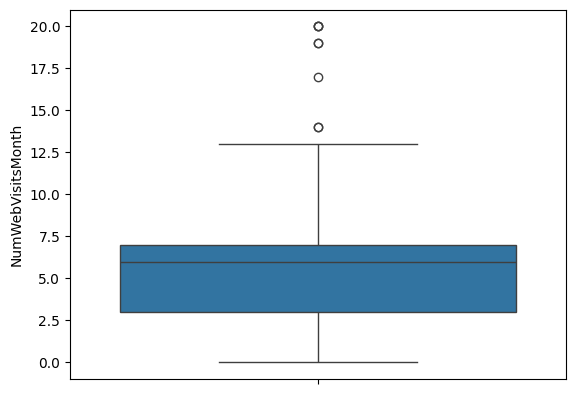

In [ ]:
sns.boxplot(df["NumWebVisitsMonth"]) 

In [ ]:
# Handle outliers by clipping 
cols_to_clip = ["Income", "AmountWines", "AmountFruits", "AmountMeat", "AmountFish", "AmountSweets", "AmountGoldProds", "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumWebVisitsMonth"]

stds = df[cols_to_clip].std(axis=0)
means = df[cols_to_clip].mean(axis=0)

df[cols_to_clip] = df[cols_to_clip].clip(
    lower=means - 3 * stds,
    upper=means + 3 * stds,
    axis=1
)